# Preventive Health Analytics: Risk, Cost Drivers and Prevention Strategy

## Executive Summary

This project analyzes a health insurance dataset to better understand the main drivers of healthcare costs and explore prevention opportunities.

The analysis combines SQL exploration, risk segmentation, causal inference, and machine learning to translate data insights into practical healthcare strategy perspectives.

Key findings include:

- **Smoking is the strongest cost driver**, increasing healthcare expenses by more than **$23,000 per year** on average.
- Individuals combining multiple lifestyle risks, particularly **smoking and obesity**, generate the highest medical costs.
- A relatively small portion of the population accounts for a **disproportionate share of healthcare spending**.

Beyond prediction, the analysis explores how **data-driven insights could support prevention strategies**, improving both healthcare sustainability and population health outcomes.

## 1. Introduction

Healthcare costs have been rising in many countries. Understanding the factors that influence medical expenses is important not only for insurance companies but also for healthcare planning and prevention strategies.

In this project, I explore a health insurance dataset to analyze how demographic and lifestyle factors influence healthcare costs.
The analysis combines two complementary perspectives:

A **business** view, focused on identifying population segments associated with higher healthcare costs and understanding where prevention strategies could have the greatest impact.

A **data science** view, focused on predicting healthcare expenses and identifying high-risk individuals.

The main questions guiding this analysis are:

- Which factors are associated with higher healthcare costs?
- Are there identifiable population profiles that generate higher medical expenses?
- Could prevention strategies reduce long-term healthcare spending?

The goal is not only to predict costs, but also to understand how prevention can reduce health risks, improve outcomes, and help keep healthcare more affordable for individuals.


## 2. Analytical Objectives

The main objectives of this analysis are:

- Identify key drivers of healthcare costs   
- Detect high-risk population segments  
- Understand the impact of lifestyle behaviors, such as smoking  
- Evaluate how prevention strategies could reduce healthcare spending  

## 3. Analytical Workflow

The analysis follows a structured workflow, progressing from data exploration to strategic insights:

1. SQL-based exploration of cost metrics  
2. Exploratory data analysis and visualization  
3. Identification of risk factors and interactions  
4. Risk cohort segmentation  
5. Health risk scoring  
6. Causal inference analysis  
7. Predictive modeling  
8. Experiment design (A/B testing simulation)  
9. Preventive health insights  

Each step builds on the previous one, moving from descriptive analysis to actionable recommendations.

## 4. Dataset Overview

This project uses a public health insurance dataset originally published on Kaggle. It contains demographic and lifestyle information about insured individuals and their medical costs.

**Source**: https://www.kaggle.com/datasets/mirichoi0218/insurance

In [30]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Colab Notebooks/10.Health_Insurance/insurance.csv'
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 4.1 Dataset Variables
Each row represents one insured individual and includes variables related to personal characteristics and medical costs. The dataset contains the following variables:

- `age` – age of the insured individual
- `sex` – gender
- `bmi` – body mass index
- `children` – number of dependents covered by the insurance
- `smoker` – whether the individual is a smoker
- `region` – geographic region
- `charges` – annual medical insurance costs

The first rows of the dataset are shown below.

In [31]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 4.2 Dataset Summary


An initial inspection was conducted to understand the structure of the dataset.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The dataset contains:

- **1338 observations**
- **7 variables**
- No missing values

The target variable used in this analysis is `charges`, representing annual medical costs.

## 5. Data Governance and Responsible Use

Health data is highly sensitive and requires careful handling.

Even though the dataset used in this project is anonymized, real-world healthcare analytics must consider several important governance principles, including:

- secure data storage
- anonymization of personal data
- compliance with regulations such as **GDPR (Europe)** and **LGPD (Brazil)**

Predictive models in healthcare can also raise ethical concerns, especially if used to adjust insurance pricing or restrict coverage for higher-risk individuals.

In this project, the focus is on using data to **better understand risk factors and support prevention strategies**, rather than simply reducing costs.

## 6. SQL-Based Analysis

In many analytics workflows, data is initially explored using SQL.

To simulate this process, the dataset is loaded into a SQLite database and analyzed using SQL queries.

The main questions explored include:

- How do healthcare costs differ between **smokers** and **non-smokers**?
- How do costs change across **age** groups?
- Does **BMI** influence healthcare spending?
- Do risk factors interact (for example, **smoking** combined with **obesity**)?
- Which individuals generate the highest medical expenses?

These insights guide the next steps of the analysis.

### 6.1 Loading the data into SQLite

The next code block creates a SQLite database and writes the dataset into a table called `insurance`.

After that, we will run a sequence of SQL queries and interpret the results in a business + prevention context.

In [34]:
import sqlite3
conn = sqlite3.connect("insurance.db")
df.to_sql("insurance", conn, if_exists="replace", index=False)
# sanity check
pd.read_sql("SELECT COUNT(*) as n_rows FROM insurance;", conn)

,n_rows
0,1338


### 6.2 Smoking Status and Healthcare Costs

The first SQL query compares healthcare costs between **smokers** and **non-smokers**.

In [35]:
query = """
SELECT
  smoker,
  COUNT(*) AS population,
  ROUND(AVG(charges), 2) AS avg_cost,
  ROUND(MIN(charges), 2) AS min_cost,
  ROUND(MAX(charges), 2) AS max_cost
FROM insurance
GROUP BY smoker;
"""
pd.read_sql(query, conn)

,smoker,population,avg_cost,min_cost,max_cost
0,no,1064,8434.27,1121.87,36910.61
1,yes,274,32050.23,12829.46,63770.43


The results reveal a large difference between the two groups:

* Smokers represent **~20%** of the population
* Average healthcare cost for smokers: **~\$32,050**
* Average healthcare cost for non-smokers: **~\$8,434**

This means smokers generate **nearly four times higher medical costs** on average.

This is the first strong indication that smoking is a major cost driver in the dataset, this insight will be further explored and validated in the next stages of the analysis.

### 6.3 Age and Healthcare Costs

The second SQL analysis examines how healthcare costs vary across **age groups**.

In [36]:
query = """
SELECT
  CASE WHEN age < 30 THEN '18-29'
      WHEN age < 40 THEN '30-39'
      WHEN age < 50 THEN '40-49'
      ELSE '50+'
    END AS age_group,
  COUNT(*) AS population,
  ROUND(AVG(charges),2) AS avg_cost
FROM insurance
GROUP BY age_group
ORDER BY age_group;
"""
pd.read_sql(query, conn)

,age_group,population,avg_cost
0,18-29,417,9182.49
1,30-39,257,11738.78
2,40-49,279,14399.20
3,50+,385,17902.55


Average medical expenses **increase steadily with age**.

Average costs rise steadily from about **\$9,182** in the youngest group to nearly **\$17,903** among individuals aged 50 and above.


### 6.4 BMI and Healthcare Costs

The third SQL analysis explores the relationship between **Body Mass Index (BMI)** and healthcare costs.

In [37]:
query = """
SELECT
  CASE WHEN bmi < 25 THEN 'Normal'
      WHEN bmi < 30 THEN 'Overweight'
      ELSE 'Obese'
    END AS bmi_category,
  COUNT(*) AS population,
  ROUND(AVG(charges),2) AS avg_cost
FROM insurance
GROUP BY bmi_category
ORDER BY avg_cost;
"""
pd.read_sql(query, conn)

,bmi_category,population,avg_cost
0,Normal,245,10282.22
1,Overweight,386,10987.51
2,Obese,707,15552.34


Healthcare expenses increase as BMI rises.

Individuals classified as obese have an average annual healthcare cost of approximately **\$15,552**, compared with **\$10,282** for individuals with normal BMI.

Another important observation is the population distribution:

- **Normal BMI:** 245 individuals  
- **Obese:** 707 individuals

This suggests that weight-related health risks affect a large portion of the population in the dataset.

### 6.5 Risk Cohorts: Interaction Between Smoking and BMI

While smoking and BMI each influence healthcare costs individually, an important question is whether these factors **interact with each other**.


In [38]:
query = """
SELECT
  smoker,
  CASE WHEN bmi < 25 THEN 'Normal'
      WHEN bmi < 30 THEN 'Overweight'
      ELSE 'Obese'
    END AS bmi_category,
  COUNT(*) AS population,
  ROUND(AVG(charges),2) AS avg_cost
FROM insurance
GROUP BY smoker, bmi_category
ORDER BY avg_cost DESC;
"""
pd.read_sql(query, conn)

,smoker,bmi_category,population,avg_cost
0,yes,Obese,145,41557.99
1,yes,Overweight,74,22495.87
2,yes,Normal,55,19839.28
3,no,Obese,562,8842.69
4,no,Overweight,312,8257.96
5,no,Normal,190,7515.71


The interaction between smoking and BMI reveals one of the strongest patterns in the dataset. Individuals who are **both smokers and obese** have an average healthcare cost of approximately $41,558 per year.

This is significantly higher than the average cost for non-smokers in any BMI category:

- **Non-smokers with normal BMI average:** ~$7,516

- **Smokers with obesity average:** ~$41,000

This means the highest-risk cohort generates **more than five times higher healthcare costs** compared with the lowest-risk group.


## 7. Exploratory Data Analysis

After the initial SQL exploration, the next step is to examine the distribution of healthcare costs in more detail.

At this stage, I focus on understanding:

- how medical expenses are distributed across the population
- whether a small group of individuals generates a large share of total costs
- how lifestyle factors relate to high healthcare spending

### 7.1 Distribution of Healthcare Costs

The histogram below shows the overall distribution of **annual healthcare costs**.



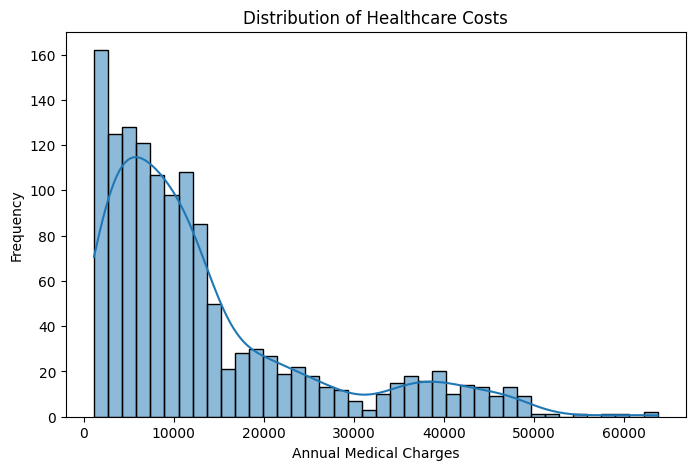

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], bins=40, kde=True)
plt.title("Distribution of Healthcare Costs")
plt.xlabel("Annual Medical Charges")
plt.ylabel("Frequency")
plt.show()

The distribution is **strongly right-skewed**.

Key observations from the distribution:

- Most individuals have annual costs between **\$1,000** and **\$15,000**.  
- Healthcare expenses above **\$30,000** are relatively rare  
- A small number of individuals generate costs exceeding **\$60,000**

### 7.2 Defining High-Cost Patients

To better understand healthcare spending patterns, I classify individuals in the **top 20% of healthcare expenses** as high-cost patients.

In [40]:
threshold = df["charges"].quantile(0.8)
print(f"Threshold for the top 20% of healthcare costs per year: ${threshold:,.0f}")

Threshold for the top 20% of healthcare costs per year: $20,261


The threshold for the top 20% in this dataset is approximately **$20,260 per year**.

Individuals above this value are considered part of the **high-cost segment**.

Focusing on this group helps organizations:

- identify risk drivers
- detect preventable conditions
- design targeted health interventions


### 7.3 High-Cost Population Overview

Here I create a new variable that identifies whether an individual belongs to the **high-cost group**.

In [41]:
df["high_cost"] = (df["charges"] >= threshold).astype(int)
counts = df["high_cost"].value_counts()
pd.DataFrame({"count": counts, "proportion": (counts / len(df)).round(2)})

,count,proportion
high_cost,,
0,1070,0.8
1,268,0.2


After applying the threshold, the dataset is divided into two groups:

- **High-cost patients:** top 20% of medical expenses  
- **Remaining population:** bottom 80%

The next step is to examine how this high-cost segment relates to key lifestyle risk factors, starting with smoking status.

### 7.4 Smoking and High-Cost Risk

The next table compares smoking status with the **high-cost patient segment**.

In [42]:
pd.crosstab(df["smoker"], df["high_cost"])

high_cost,0,1
smoker,,
no,1004,60
yes,66,208


Although smokers represent a minority of the dataset, they account for the majority of high-cost cases.

Key numbers:

- **208 smokers** belong to the high-cost group  
- **60 non-smokers** fall into the same category

This result reinforces the pattern observed in the SQL analysis: smokers are significantly more likely to generate high healthcare costs.

Instead of being an isolated factor, smoking consistently appears as a key driver across different analytical approaches.

### 7.5 Health Risk Score

To simplify the interpretation of multiple risk factors, a simple **health risk score** is created based on three variables:

- smoking status
- BMI above 30
- age above 50

The scoring system assigns:

- **+2 points** if the individual is a smoker  
- **+1 point** if BMI is above 30  
- **+1 point** if age is above 50  

This creates a risk scale ranging from **0 (lowest risk) to 4 (highest risk)**.

The table below shows how individuals in the dataset are distributed across the different risk score levels.

In [43]:
df["risk_score"] = ((df["smoker"] == "yes").astype(int)*2 +(df["bmi"] > 30).astype(int) +(df["age"] > 50).astype(int))
df["risk_score"].value_counts().sort_index().rename(index=lambda x: f"Risk Score {x}").to_frame("count")

,count
risk_score,
Risk Score 0,392
Risk Score 1,491
Risk Score 2,285
Risk Score 3,132
Risk Score 4,38


Most individuals fall within the **lower risk categories (scores 0–2)**, while a smaller portion of the population belongs to the **highest risk levels (3 and 4)**.


### 7.6 Risk Score and Healthcare Costs

The next step is to evaluate how healthcare costs change across different **risk score levels**.

In [44]:
result = df.groupby("risk_score")["charges"].mean()
result = result.rename(index=lambda x: f"Risk Score {x}").to_frame("Charges")
result["Charges"] = result["Charges"].map(lambda x: f"${x:,.0f}")
result

,Charges
risk_score,
Risk Score 0,"$6,477"
Risk Score 1,"$8,045"
Risk Score 2,"$16,066"
Risk Score 3,"$37,032"
Risk Score 4,"$47,369"


When comparing healthcare costs across different risk score levels, a clear pattern emerges: medical expenses increase significantly as risk factors accumulate.

Individuals in the highest risk category generate **more than seven times the average cost** of the lowest-risk group:

- **Risk score 0:** ~\$6,477
- **Risk score 4:** ~\$47,369

### 7.7 Visualizing Risk Score Impact

To better illustrate this pattern, we visualize the relationship between the risk score and average healthcare costs.

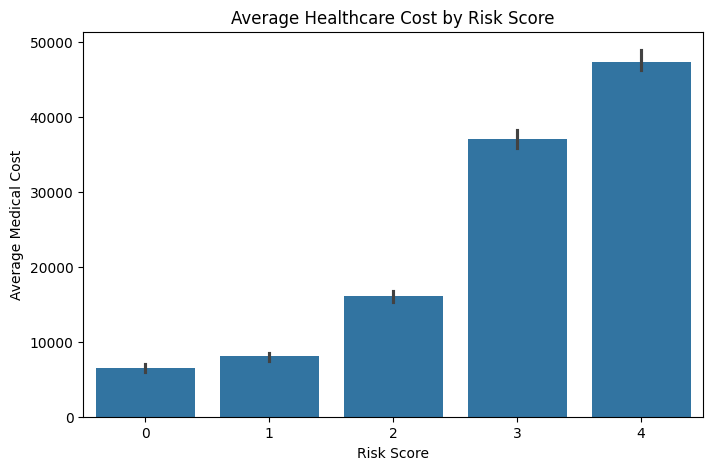

In [45]:
import numpy as np
plt.figure(figsize=(8,5))
sns.barplot(x="risk_score", y="charges", data=df, estimator= np.mean)
plt.title("Average Healthcare Cost by Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Average Medical Cost")
plt.show()

The chart below illustrates how **healthcare costs increase as the risk score rises**.

Key observations:

- Low-risk individuals (score 0–1) generate relatively moderate healthcare expenses.
- Costs rise significantly for **risk score 2**, indicating the impact of multiple risk factors.
- The highest risk levels (**scores 3 and 4**) correspond to dramatically higher medical costs.

### Strategic takeaway

A simple risk score can be a powerful tool for:

- early detection of high-risk individuals  
- targeted preventive health programs  
- improved healthcare cost forecasting  

Instead of applying the same strategy to the entire population, organizations can focus interventions on **high-risk groups where the potential impact is greatest**.

## 8. Customer Segmentation (Clustering)

Customer segmentation is a common technique in business analytics and consulting because it helps identify groups of individuals with similar characteristics and risk profiles.

In this step, I apply **K-Means clustering** to identify potential population segments within the dataset.

The model considers the following variables:

- age
- BMI
- number of children
- healthcare costs

Before applying the clustering algorithm, the variables are standardized to ensure that differences in scale do not distort the results.

In [46]:
from sklearn.preprocessing import StandardScaler
features = df[["age", "bmi", "children", "charges"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

### 8.1 Determining the Number of Clusters using KMeans

To determine an appropriate number of clusters, is used the **Elbow Method**, which evaluates how clustering performance changes as the number of clusters increases.

The method analyzes **inertia**, a metric that measures how closely data points are grouped within each cluster.



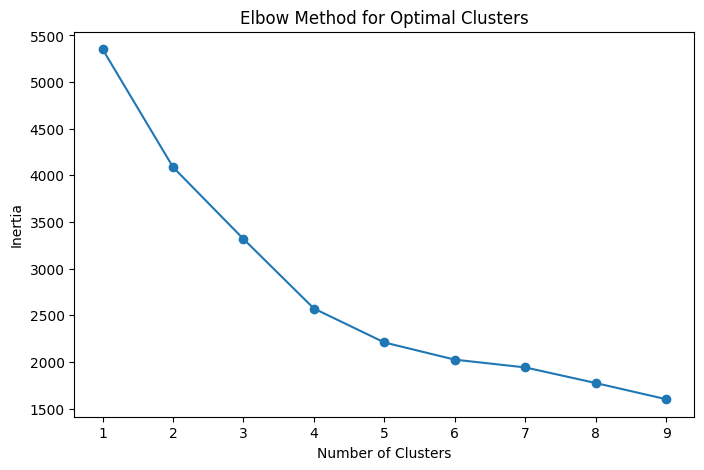

In [47]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

The curve begins to flatten around **four clusters**, so the analysis proceeds with K = 4.

Based on this result, the analysis proceeds using **K = 4 clusters**.

### 8.2 Cluster Distribution

K-Means model was fitted using the standardized variables defined earlier. Each observation then receives a cluster label.



In [48]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)
df["cluster"].value_counts().sort_index().to_frame("count")

,count
cluster,
0,408
1,165
2,346
3,419


The clusters are relatively balanced in size, although **Cluster 1 is smaller**, suggesting a more specific subgroup.

However, cluster labels themselves do not have an inherent meaning. To interpret them, is necessary to examine the average characteristics of each group.

### 8.3 Cluster Profiles

To interpret the clusters, we examine the **average characteristics of each group**.

In [49]:
df.groupby("cluster")[["age","bmi","children","charges"]].mean().round(1)

,age,bmi,children,charges
cluster,,,,
0,52.5,30.9,0.4,12593.0
1,39.9,35.3,1.1,40308.3
2,39.9,30.0,2.7,10709.6
3,25.4,29.2,0.4,5397.4


The clusters can be interpreted as follows:

**Cluster 3 – Young & Low Cost**

- youngest individuals in the dataset
- relatively low BMI
- lowest healthcare costs

This segment likely represents younger and generally healthier individuals.

**Cluster 2 – Family Segment**

- middle-aged population
- highest number of children
- moderate healthcare costs

This group may represent family households with relatively stable health profiles.

**Cluster 0 – Older Population**

- oldest individuals in the dataset
- slightly higher BMI
- moderate healthcare expenses

Age appears to be the primary driver of healthcare utilization in this segment.

**Cluster 1 – High-Risk Lifestyle Segment**

- highest BMI values
- dramatically higher healthcare costs
- average annual expenses above **$40,000**

This segment represents a high-risk population group, likely influenced by lifestyle-related health risks.

### Strategic Interpretation

Each segment suggests different possible approaches:

- **Young & low-cost group:** focus on preventive education and long-term health maintenance  
- **Family segment:** promote family health programs and preventive checkups  
- **Older population:** emphasize chronic disease management and early screening  
- **High-risk lifestyle group:** prioritize targeted interventions such as smoking cessation and weight management programs  

## 9. Causal Inference: Estimating the Effect of Smoking

The previous analysis revealed a strong relationship between smoking and healthcare costs. However, correlation alone does not necessarily imply causation.

To better estimate the causal effect of smoking on healthcare costs, is applied **Propensity Score Matching (PSM)**. This method attempts to compare smokers with non-smokers who have similar observable characteristics, reducing bias in the comparison.

The goal is to estimate how much smoking increases healthcare costs when other factors are held as similar as possible between the groups.

### 9.1 Propensity Score Estimation

To estimate the causal effect of smoking, the first step is to calculate a **propensity score**.

In this model, the probability of smoking is estimated using:

- age
- BMI
- number of children

A **logistic regression model** is used to estimate these probabilities.

In [50]:
from sklearn.linear_model import LogisticRegression
X = df[["age","bmi","children"]]
y = (df["smoker"]=="yes").astype(int)
log_reg = LogisticRegression()
log_reg.fit(X,y)
df["propensity_score"] = log_reg.predict_proba(X)[:,1]
df[["propensity_score","smoker"]].head()

,propensity_score,smoker
0,0.215594,yes
1,0.222106,no
2,0.219995,no
3,0.202624,no
4,0.206018,no


After fitting the model, each individual receives a propensity score representing how likely they are to be a smoker given their characteristics. These scores will later be used to match smokers with similar non-smokers.

### 9.2 Treatment and Control Groups

For the causal analysis, the dataset is divided into two groups:

- **Treatment group:** smokers  
- **Control group:** non-smokers  

In [51]:
smokers = df[df["smoker"] == "yes"]
non_smokers = df[df["smoker"] == "no"]
groups = pd.DataFrame({"Group": ["Non-smokers", "Smokers"],"Population": [len(non_smokers), len(smokers)]})
groups

,Group,Population
0,Non-smokers,1064
1,Smokers,274




Because the groups are very different in size, direct comparisons may be biased.

The next step is to match individuals with similar propensity scores to create comparable groups.

### 9.3 Estimated Causal Effect of Smoking

After matching smokers with non-smokers who have similar characteristics (age, BMI, and number of children), we compare their healthcare costs.


In [52]:
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=1).fit(non_smokers[["propensity_score"]])
indices = nbrs.kneighbors(smokers[["propensity_score"]], return_distance=False)
matched_df = smokers.copy()
matched_df["matched_cost"] = non_smokers.iloc[indices.flatten()]["charges"].values
pd.DataFrame({"Group": ["Smokers", "Matched Non-Smokers"],
    "Average Cost": [f"${matched_df['charges'].mean():,.0f}",f"${matched_df['matched_cost'].mean():,.0f}"]})

,Group,Average Cost
0,Smokers,"$32,050"
1,Matched Non-Smokers,"$8,541"


The results show a substantial difference between the two groups.

- **Average cost for smokers:** ~\$32,050  
- **Average cost for matched non-smokers:** ~\$8,540  

This suggests that smoking is associated with an increase of roughly **\$23,500** in annual healthcare costs per individual.

### Strategic Interpretation

Although observational data cannot prove perfect causality, Propensity Score Matching helps reduce bias by comparing individuals with similar characteristics.

The result reinforces earlier findings: **smoking is the strongest cost driver** in this dataset.

## 10. Experimental Design: Evaluating a Smoking Cessation Program (A/B Testing)

The previous analysis suggests that smoking is strongly associated with higher healthcare costs. This naturally raises an important question: **could prevention programs reduce these costs?**

We can evaluate this through a  **A/B testing** setup for a smoking cessation program.

A potential experiment could be designed as follows:

* **Objective**: Evaluate whether a smoking cessation program reduces healthcare costs  

* **Control group**: Smokers who do not receive the intervention.

* **Treatment group**: Smokers who participate in the cessation program.

* **Outcome metric**: Average healthcare costs per patient over time.

### 10.1 Potential Impact of a Smoking Cessation Program

Using the causal analysis results from the previous section, we can simulate the potential **economic impact of reducing smoking-related risk**.


In [53]:
smoker_cost = smokers["charges"].mean()
matched_cost = matched_df["matched_cost"].mean()
pd.DataFrame({"Scenario": ["Current smokers", "Comparable non-smokers"],"Average Cost": [f"${smoker_cost:,.0f}", f"${matched_cost:,.0f}"]})

,Scenario,Average Cost
0,Current smokers,"$32,050"
1,Comparable non-smokers,"$8,541"


- **Current smokers:** ~\$32,050 average annual cost  
- **Comparable non-smokers:** ~\$8,541  

This suggests a potential cost gap of approximately **$23,500 per patient per year**.

In a real-world setting, the goal would be to observe whether participants in the cessation program gradually move closer to the cost profile of non-smokers.

Even partial reductions in smoking rates could lead to meaningful decreases in healthcare costs, while also improving overall health outcomes.

## 11. Predictive Modeling

The final analytical stage of the project focuses on predictive modeling.

At this point, the goal is to explore whether machine learning models can help anticipate healthcare costs and identify individuals who may generate higher medical expenses.

Two predictive tasks are considered:

1. **Cost prediction (regression)**  
   Estimate expected healthcare costs based on demographic and lifestyle variables.

2. **High-cost classification**  
   Identify individuals who are more likely to fall into the high-cost segment.

These models can support healthcare organizations in:

- forecasting healthcare expenses  
- identifying high-risk individuals earlier  
- designing targeted prevention strategies

### 11.1 Train-Test Split

To evaluate model performance, the dataset is divided into **training and testing sets**.

- **Training set:** 80% of the data  
- **Test set:** 20% of the data  

In [54]:
from sklearn.model_selection import train_test_split
features = ["age","bmi","children","smoker","sex","region"]
df_model = pd.get_dummies(df[features], drop_first=True)
X = df_model
y = df["charges"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape

(1070, 8)

This results in:

- **1,070 observations** used for training  
- **268 observations** used for testing

### 11.2 Linear Regression Results

The first model trained is a **Linear Regression**, a commonly used baseline model for predicting healthcare costs.

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, pred_lr)
r2_lr = r2_score(y_test, pred_lr)
results = pd.DataFrame({"Metric": ["MAE", "R²"],"Value": [f"${mae_lr:,.0f}", f"{r2_lr:.2f}"]})
results

,Metric,Value
0,MAE,"$4,181"
1,R²,0.78



The model explains approximately 78% of the variance in healthcare costs, which indicates a **strong relationship between the selected variables and medical expenses**.

The Mean Absolute Error (MAE) suggests that the model's predictions are, on average, **within $4,181 of the actual healthcare costs**.

Although simple, the model already captures a substantial portion of the relationship between demographic and lifestyle factors and medical expenses.

### 11.3 Random Forest Results

To capture more complex relationships between variables, we train a **Random Forest Regressor**, a model capable of handling non-linear interactions.

In [56]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, pred_rf)
r2_rf = r2_score(y_test, pred_rf)
model_results = pd.DataFrame({"Model": ["Linear Regression", "Random Forest"],"MAE": [f"${mae_lr:,.0f}", f"${mae_rf:,.0f}"],"R²": [f"{r2_lr:.2f}", f"{r2_rf:.2f}"]})
model_results

,Model,MAE,R²
0,Linear Regression,"$4,181",0.78
1,Random Forest,"$2,560",0.86


The comparison os the metric values shows that Random Forest model significantly improves predictive performance:

* Random Forest explains about **86% of the variation in healthcare costs**, comparing with 78% from the Linear Regression,

* The **average prediction error also decreases to about $2,560** on Random Forest model.

The improvement suggests that healthcare costs are influenced by **non-linear interactions between variables**, which tree-based models can capture more effectively.

### 11.4 Feature Importance

To better understand which variables contribute most to the model’s predictions, we examine **feature importance** from the Random Forest model.

In [57]:
feature_table = (pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).reset_index().rename(columns={"index": "Feature", 0: "Importance"}))
feature_table["Importance"] = feature_table["Importance"].apply(lambda x: "<0.01" if x < 0.01 else f"{x:.2f}")
feature_table

,Feature,Importance
0,smoker_yes,0.61
1,bmi,0.21
2,age,0.13
3,children,0.02
4,sex_male,<0.01
5,region_northwest,<0.01
6,region_southeast,<0.01
7,region_southwest,<0.01


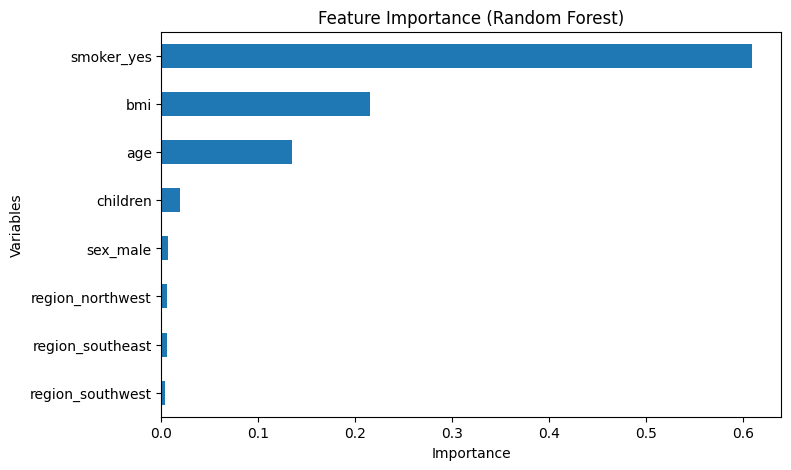

In [58]:
feature_importance = pd.Series(rf.feature_importances_,index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
feature_importance.sort_values().plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.show()

#### Strategic Interpretation

The result reinforce the patterns observed earlier in the analysis:

* **Smoking** is the strongest cost driver  (~*60% importance)
* **BMI** is the second strongest predictor
* **Age** is also an important contributor

The model confirms that these variables play a central role in predicting healthcare costs in this dataset.

Other variables such as region, gender, and number of children have relatively small effects on predicted healthcare costs.

## 12. Business and Prevention Insights

Across the different stages of this analysis, a consistent pattern emerges: a small number of lifestyle factors drive a large share of healthcare costs.

The most influential drivers identified in the analysis are:

- **Smoking status**
- **Body Mass Index (BMI)**
- **Age**

Smoking stands out as the strongest contributor to high medical expenses. Both the causal analysis and the predictive models suggest that smokers generate significantly higher healthcare costs.

The analysis also highlights the presence of distinct **risk cohorts** in the population. Individuals combining multiple risk factors (particularly smoking and high BMI) form the highest-cost segment in the dataset.

These findings suggest that prevention strategies may be more effective when focused on high-risk groups rather than the entire population.

Examples of **potential initiatives** include:

- smoking cessation programs  
- weight management and lifestyle support  
- early risk identification for high-risk cohorts

Instead of focusing only on predicting costs, data analytics can help address the underlying factors that drive them, supporting both **cost reduction** and **better health outcomes**.

## 13. Limitations

This analysis has some limitations that should be considered:

* **Dataset size**: The dataset is relatively small (**1,338 observations**), while real-world healthcare analytics typically relies on much larger and more diverse datasets.

* **Limited health variables**: Important factors such as medical history, physical activity, diet, and genetic predispositions are not included in the dataset.

* **Cross-sectional data**: The dataset represents a single snapshot in time. Longitudinal healthcare data would allow better modeling of disease progression and prevention impact.

* **Model scope**: The predictive models should be interpreted as analytical tools rather than decision systems. Real-world deployment would require additional validation with larger datasets.

Despite these limitations, the analysis still provides useful insights into the main drivers of healthcare costs.

## 14. Strategic Summary

This project explores how data analytics can identify healthcare cost drivers and support more effective prevention strategies.

By combining data analysis, causal inference, experimentation, and predictive modeling, it shows how analytics can improve decision-making and reduce long-term healthcare costs.

The most important findings include:
* **Smoking is the strongest cost driver**: Causal analysis suggests that smoking increases healthcare costs by approximately **$23,500** per patient per year.
* **BMI and age are important secondary predictors**: Higher BMI and older age are consistently associated with increased healthcare utilization.
* **Risk factors accumulate**: Individuals combining smoking and obesity form the **highest-cost cohort** in the dataset.

These results highlight the importance of focusing on high-risk groups rather than applying broad interventions.

From a strategic perspective, prevention strategies targeting a small number of high-risk groups may have a disproportionate impact on healthcare spending.

Rather than focusing only on predicting costs, analytics can also support **evidence-based prevention strategies**, helping address the lifestyle factors that drive long-term health outcomes.

These insights also motivate the next step explored in the accompanying notebook: using **Retrieval-Augmented Generation (RAG)** to combine analytical results with external medical knowledge and build a simple assistant capable of explaining health risks and prevention strategies.
